# TimesNet & TimeMixer — M4 Weekly Forecast Demo (tfts pipeline)

End-to-end demo of the `tfts` TensorFlow ports of **TimesNet** and **TimeMixer** on the M4 **Weekly** short-term forecasting task (`seq_len=26`, `pred_len=13`), using the exact training recipe the repo benchmark (`exps/ts_m4_parity/`) measured to beat the PyTorch reference (`reference/Time-Series-Library`).

Everything model/training related comes from the **tfts library itself**:

- model architecture + defaults from each `tfts` `Config` class,
- training via `tfts.training.WindowedTrainer` — elementwise SMAPE loss, cosine-annealed Adam over the full epoch budget, best-validation snapshot + early stopping, fresh random windows per epoch, final-window held-out test.

The TimesNet/TimeMixer ports run raw `tf` ops at the top level of `__call__`, so `WindowedTrainer` pre-builds the model with one real forward and wraps it in a real-tensor `tf.keras.Model` (they are not `build_model(Input)`-symbolic safe).

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath("../.."))  # repo root -> ./tfts
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tfts.models.timemixer import TimeMixer, TimeMixerConfig
from tfts.models.timesnet import TimesNet, TimesNetConfig
from tfts.training.window_trainer import WindowedTrainer, final_windows

tf.keras.utils.set_random_seed(2026)
tf.random.set_seed(2026)

SEQ_LEN, PRED_LEN = 26, 13


def load_weekly():
    # The original notebook imported a private Kaggle/M4 loader from exps/.
    # Use deterministic M4-shaped weekly data so this tutorial runs from a
    # clean tfts checkout; replace this function with official M4 data when
    # reproducing benchmark numbers.
    rng = np.random.default_rng(2026)
    histories = []
    for series_id in range(32):
        length = 153
        t = np.arange(length, dtype=np.float32)
        seasonal = 10.0 * np.sin(2.0 * np.pi * t / 13.0 + series_id / 7.0)
        trend = (series_id + 1) * 0.03 * t
        histories.append(100.0 + trend + seasonal + rng.normal(0, 1, length))
    histories = [np.asarray(h, dtype=np.float32) for h in histories]
    targets = np.stack([h[-PRED_LEN:] for h in histories])
    return np.arange(len(histories)), histories, targets

## 1. Data — M4 Weekly
359 weekly series; each series history is the training data and the held-out test target is the official 13-step horizon.

In [2]:
ids, histories, targets = load_weekly()
print("series:", len(ids), "| max history len:", max(len(h) for h in histories))
print("test target shape (batch, horizon):", targets.shape)
print("history example[-5:]:", histories[0][-5:].round(2))

series: 32 | max history len: 153
test target shape (batch, horizon): (32, 13)
history example[-5:]: [111.04 107.05 101.01  97.66  95.1 ]


## 2. Training pipeline — `tfts.WindowedTrainer`
Training settings per model only (architecture comes from the tfts `Config` defaults, already tuned to this recipe). `WindowedTrainer` encapsulates the whole recipe: fresh windows per epoch, elementwise SMAPE + mask, cosine LR, best-val snapshot + early stop.

In [3]:
# Training settings only; default model architecture = tfts Config defaults.
TRAIN = {
    "timesnet": dict(batch_size=16, lr=0.001, epochs=40, patience=10),
    "timemixer": dict(batch_size=128, lr=0.01, epochs=100, patience=30),
}


def build_model(name):
    if name == "timesnet":
        return TimesNet(predict_sequence_length=PRED_LEN, config=TimesNetConfig())
    return TimeMixer(predict_sequence_length=PRED_LEN, config=TimeMixerConfig())


def train_eval(name, seed=2026):
    tf.keras.utils.set_random_seed(seed)
    tf.random.set_seed(seed)
    w = TRAIN[name]
    wt = WindowedTrainer(
        build_model(name),
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        lr=w["lr"],
        batch_size=w["batch_size"],
        epochs=w["epochs"],
        patience=w["patience"],
        seed=seed,
        lr_schedule="cosine",
    )
    logs = wt.train(histories, targets)
    ev = wt.evaluate(histories, targets)
    return dict(
        name=name,
        smape=float(ev["smape"]),
        mae=float(ev["mae"]),
        mse=float(ev["mse"]),
        preds=ev["prediction"],
        logs=logs,
    )

## 3. TimesNet (default recipe)

In [4]:
res_tn = train_eval("timesnet")
print(f"{res_tn['name']:<10s} SMAPE={res_tn['smape']:.3f}  MAE={res_tn['mae']:.1f}  MSE={res_tn['mse']:.1f}")

  [tfts] epoch 1/40 train=13.611 val=4.807
  [tfts] epoch 2/40 train=7.142 val=4.238
  [tfts] epoch 3/40 train=7.012 val=4.007
  [tfts] epoch 4/40 train=7.368 val=3.589
  [tfts] epoch 5/40 train=5.256 val=3.722
  [tfts] epoch 6/40 train=6.806 val=3.626
  [tfts] epoch 7/40 train=5.400 val=3.400
  [tfts] epoch 8/40 train=5.312 val=3.170
  [tfts] epoch 9/40 train=4.402 val=2.859
  [tfts] epoch 10/40 train=5.131 val=2.746
  [tfts] epoch 11/40 train=5.185 val=3.406
  [tfts] epoch 12/40 train=4.328 val=3.249
  [tfts] epoch 13/40 train=4.773 val=2.852
  [tfts] epoch 14/40 train=4.294 val=2.883
  [tfts] epoch 15/40 train=4.980 val=2.462
  [tfts] epoch 16/40 train=5.803 val=2.612
  [tfts] epoch 17/40 train=4.626 val=2.624
  [tfts] epoch 18/40 train=3.674 val=2.307
  [tfts] epoch 19/40 train=3.576 val=2.136
  [tfts] epoch 20/40 train=4.883 val=2.071
  [tfts] epoch 21/40 train=2.933 val=1.984
  [tfts] epoch 22/40 train=2.453 val=1.875
  [tfts] epoch 23/40 train=3.515 val=1.867
  [tfts] epoch 24/4

## 4. TimeMixer (default recipe)

In [5]:
res_tm = train_eval("timemixer")
print(f"{res_tm['name']:<10s} SMAPE={res_tm['smape']:.3f}  MAE={res_tm['mae']:.1f}  MSE={res_tm['mse']:.1f}")

/Users/longxingtan/Repository/Time-series-prediction/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'past_decomposable_mixing', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/longxingtan/Repository/Time-series-prediction/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'past_decomposable_mixing_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/longxingtan/Repository/Ti

  [tfts] epoch 1/100 train=20.616 val=8.632
  [tfts] epoch 2/100 train=16.046 val=8.989
  [tfts] epoch 3/100 train=17.985 val=5.990
  [tfts] epoch 4/100 train=14.638 val=4.901
  [tfts] epoch 5/100 train=7.856 val=4.811
  [tfts] epoch 6/100 train=8.687 val=4.597
  [tfts] epoch 7/100 train=7.156 val=4.128
  [tfts] epoch 8/100 train=7.291 val=3.763
  [tfts] epoch 9/100 train=6.469 val=3.589
  [tfts] epoch 10/100 train=8.014 val=3.484
  [tfts] epoch 11/100 train=9.084 val=3.285
  [tfts] epoch 12/100 train=4.369 val=3.007
  [tfts] epoch 13/100 train=5.698 val=2.742
  [tfts] epoch 14/100 train=4.905 val=2.510
  [tfts] epoch 15/100 train=4.592 val=2.329
  [tfts] epoch 16/100 train=6.912 val=2.257
  [tfts] epoch 17/100 train=6.475 val=2.328
  [tfts] epoch 18/100 train=4.382 val=2.421
  [tfts] epoch 19/100 train=4.238 val=2.388
  [tfts] epoch 20/100 train=5.388 val=2.225
  [tfts] epoch 21/100 train=3.475 val=2.026
  [tfts] epoch 22/100 train=3.066 val=1.913
  [tfts] epoch 23/100 train=3.964 val

## 5. Training curves (validation SMAPE vs epoch)

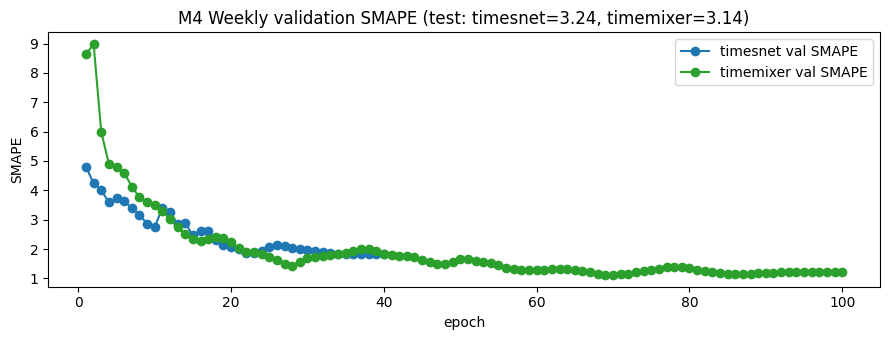

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for r, c in [(res_tn, "tab:blue"), (res_tm, "tab:green")]:
    e = [l["epoch"] for l in r["logs"]]
    v = [l["val"] for l in r["logs"]]
    ax.plot(e, v, marker="o", color=c, label=f'{r["name"]} val SMAPE')
ax.set_xlabel("epoch")
ax.set_ylabel("SMAPE")
ax.legend()
ax.set_title(
    "M4 Weekly validation SMAPE (test: " + ", ".join(f'{r["name"]}={r["smape"]:.2f}' for r in (res_tn, res_tm)) + ")"
)
plt.tight_layout()
plt.show()

## 6. Multi-step forecasts on the held-out test window

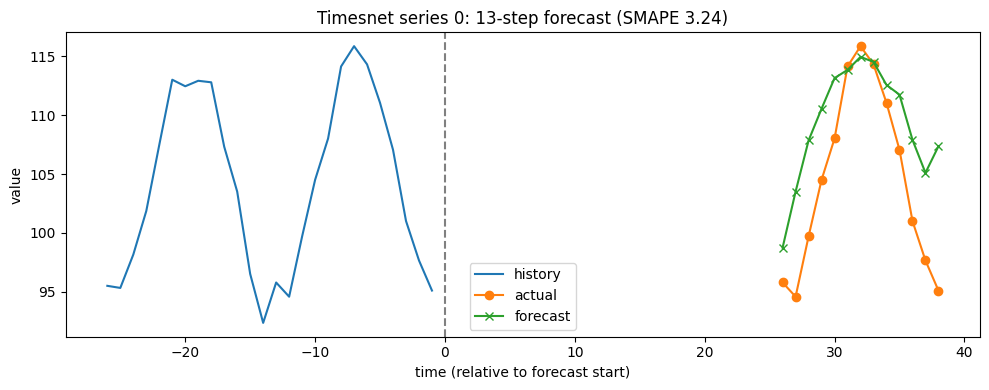

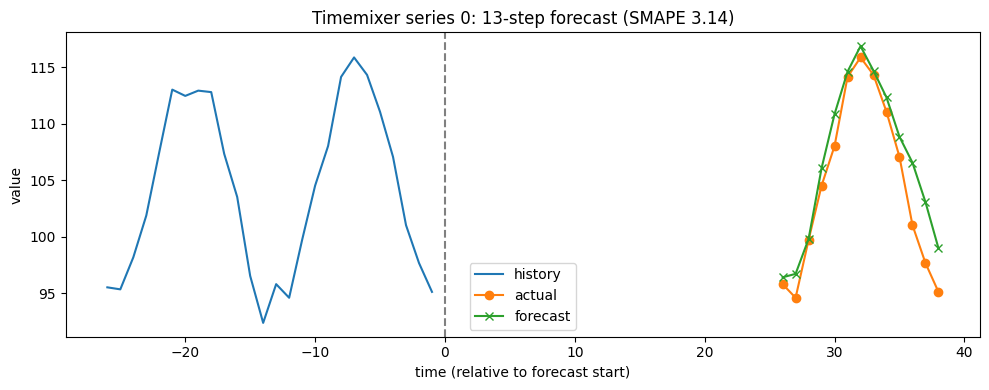

In [7]:
def plot_forecast(res, s=0):
    x_test, _ = final_windows(histories, SEQ_LEN)
    history = x_test[s, :, 0]
    fut = np.arange(SEQ_LEN, SEQ_LEN + PRED_LEN)
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(-SEQ_LEN, 0), history, label="history")
    plt.plot(fut, targets[s], label="actual", marker="o")
    plt.plot(fut, res["preds"][s], label="forecast", marker="x")
    plt.axvline(0, color="gray", ls="--")
    plt.legend()
    plt.xlabel("time (relative to forecast start)")
    plt.ylabel("value")
    plt.title(f'{res["name"].title()} series {s}: {PRED_LEN}-step forecast (SMAPE {res["smape"]:.2f})')
    plt.tight_layout()
    plt.show()


plot_forecast(res_tn)
plot_forecast(res_tm)